In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import time
import copy
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Dirichlet

warnings.filterwarnings("ignore")

In [ ]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_REWARD_DIR = f"{PROJECT_ROOT}/outputs/reward_comparison"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_REWARD_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

with open(f"{CONFIGS_DIR}/feature_columns.json", "r") as f:
    feature_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]
SEED = master_cfg["seed"]
FEATURE_COLS = feature_cfg["feature_columns"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRANSACTION_COST = 0.001

# Transformer config
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 2
FF_DIM = 256
DROPOUT = 0.1

# PPO config
LR = 3e-4
WEIGHT_DECAY = 1e-5

GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.001
MAX_GRAD_NORM = 0.5

TRAIN_EPOCHS = 60
PPO_UPDATES_PER_EPOCH = 10
MINIBATCH_SIZE = 128

DIRICHLET_CONC_MIN = 5.0
DIRICHLET_CONC_MAX = 200.0

RUN_NAME_COST_10Y = "transformer_ppo_costaware_10y"
RUN_NAME_NO_COST_10Y = "transformer_ppo_nocost_10y"

MODEL_DIR_COST_10Y = f"{OUTPUTS_MODEL_DIR}/{RUN_NAME_COST_10Y}"
MODEL_DIR_NO_COST_10Y = f"{OUTPUTS_MODEL_DIR}/{RUN_NAME_NO_COST_10Y}"

os.makedirs(MODEL_DIR_COST_10Y, exist_ok=True)
os.makedirs(MODEL_DIR_NO_COST_10Y, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("MODEL_DIR_COST_10Y:", MODEL_DIR_COST_10Y)
print("MODEL_DIR_NO_COST_10Y:", MODEL_DIR_NO_COST_10Y)

DEVICE: cpu
MODEL_DIR_COST_10Y: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_costaware_10y
MODEL_DIR_NO_COST_10Y: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_nocost_10y


In [ ]:
# ============================================================
# CELL 04 — Load standardized 10Y bundle
# ============================================================

bundle_10y = np.load(f"{DATA_PROCESSED_DIR}/tensor_bundle_10y.npz", allow_pickle=True)

X_raw_10y = bundle_10y["X"].astype(np.float32)
y_10y = bundle_10y["y"].astype(np.float32)
dates_10y = pd.to_datetime(bundle_10y["dates"])
splits_10y = bundle_10y["splits"]

print("X_raw_10y:", X_raw_10y.shape)
print("y_10y:", y_10y.shape)
print("dates_10y:", dates_10y.shape)
print("splits_10y:", splits_10y.shape)
print("unique splits:", np.unique(splits_10y, return_counts=True))

X_raw_10y: (2476, 20, 5, 13)
y_10y: (2476, 5)
dates_10y: (2476,)
splits_10y: (2476,)
unique splits: (array(['test', 'train', 'val'], dtype='<U5'), array([ 501, 1472,  503]))


In [ ]:
# ============================================================
# CELL 05 — Standardize 10Y using TRAIN only
# ============================================================

from sklearn.preprocessing import StandardScaler

train_mask = (splits_10y == "train")
val_mask = (splits_10y == "val")
test_mask = (splits_10y == "test")

scaler = StandardScaler()
train_flat = X_raw_10y[train_mask].reshape(-1, X_raw_10y.shape[-1])
scaler.fit(train_flat)

def apply_scaler_to_4d_tensor(X_4d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    original_shape = X_4d.shape
    flat = X_4d.reshape(-1, original_shape[-1])
    flat_scaled = scaler.transform(flat)
    return flat_scaled.reshape(original_shape).astype(np.float32)

X_10y = apply_scaler_to_4d_tensor(X_raw_10y, scaler)

data_10y = {
    "train": {
        "X": X_10y[train_mask],
        "y": y_10y[train_mask],
        "dates": np.array(dates_10y[train_mask].astype(str)),
    },
    "val": {
        "X": X_10y[val_mask],
        "y": y_10y[val_mask],
        "dates": np.array(dates_10y[val_mask].astype(str)),
    },
    "test": {
        "X": X_10y[test_mask],
        "y": y_10y[test_mask],
        "dates": np.array(dates_10y[test_mask].astype(str)),
    },
}

for split in ["train", "val", "test"]:
    print(split, data_10y[split]["X"].shape, data_10y[split]["y"].shape, data_10y[split]["dates"].shape)

train (1472, 20, 5, 13) (1472, 5) (1472,)
val (503, 20, 5, 13) (503, 5) (503,)
test (501, 20, 5, 13) (501, 5) (501,)


In [ ]:
# ============================================================
# CELL 06 — PortfolioEnv
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float = 0.001,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.lookback = self.X.shape[1]
        self.n_assets = self.X.shape[2]
        self.n_features = self.X.shape[3]

        self.reset()

    def reset(self) -> np.ndarray:
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        if len(action) != self.n_assets:
            raise ValueError(f"Action length {len(action)} != n_assets {self.n_assets}")
        action = np.clip(action, 1e-8, None)
        action = action / action.sum()
        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "asset_returns": r_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)
        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(next_state=next_state, reward=float(reward), done=self.done, info=info)

In [ ]:
# ============================================================
# CELL 07 — Transformer model
# ============================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        l = x.size(1)
        return x + self.pe[:, :l, :]


class TransformerEncoderState(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.input_dim = n_assets * n_features
        self.input_proj = nn.Linear(self.input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=lookback + 5)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
        )

        self.post = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, l, n, f = x.shape
        x = x.reshape(b, l, n * f)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        h = self.transformer(x)
        h_last = h[:, -1, :]
        h_last = self.post(h_last)
        return h_last


class TransformerActorCritic(nn.Module):
    def __init__(
        self,
        lookback: int,
        n_assets: int,
        n_features: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        ff_dim: int,
        dropout: float,
        conc_min: float = 5.0,
        conc_max: float = 200.0,
    ):
        super().__init__()

        self.n_assets = n_assets
        self.conc_min = conc_min
        self.conc_max = conc_max

        self.encoder = TransformerEncoderState(
            lookback=lookback,
            n_assets=n_assets,
            n_features=n_features,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
        )

        self.actor_logits = nn.Linear(d_model, n_assets)
        self.actor_concentration = nn.Linear(d_model, 1)
        self.critic = nn.Linear(d_model, 1)

    def _get_shared(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def get_policy_dist(self, x: torch.Tensor):
        h = self._get_shared(x)
        logits = self.actor_logits(h)
        mean_weights = torch.softmax(logits, dim=-1)

        raw_conc = self.actor_concentration(h)
        conc_scalar = torch.sigmoid(raw_conc)
        conc_scalar = self.conc_min + (self.conc_max - self.conc_min) * conc_scalar
        conc_scalar = conc_scalar.squeeze(-1)

        alpha = mean_weights * conc_scalar.unsqueeze(-1)
        alpha = torch.clamp(alpha, min=1e-4)

        dist = Dirichlet(alpha)
        return dist, mean_weights, alpha

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        h = self._get_shared(x)
        v = self.critic(h).squeeze(-1)
        return v

    def act(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        action = dist.rsample()
        log_prob = dist.log_prob(action)
        value = self.get_value(x)
        entropy = dist.entropy()
        return action, log_prob, value, entropy, mean_weights, alpha

    def act_deterministic(self, x: torch.Tensor):
        dist, mean_weights, alpha = self.get_policy_dist(x)
        value = self.get_value(x)
        return mean_weights, value, alpha

In [ ]:
# ============================================================
# CELL 08 — PPO helpers
# ============================================================

def compute_gae(rewards, values, dones, gamma, gae_lambda):
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    last_adv = 0.0

    for t in reversed(range(T)):
        next_value = 0.0 if t == T - 1 else values[t + 1]
        next_nonterminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last_adv = delta + gamma * gae_lambda * next_nonterminal * last_adv
        advantages[t] = last_adv

    returns = advantages + values
    return advantages.astype(np.float32), returns.astype(np.float32)


def normalize_advantages(adv: torch.Tensor) -> torch.Tensor:
    return (adv - adv.mean()) / (adv.std() + 1e-8)


def collect_rollout(model: nn.Module, env: PortfolioEnv, device: str):
    model.eval()

    states, actions, log_probs, rewards, dones, values, infos = [], [], [], [], [], [], []

    state = env.reset()

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, log_prob_t, value_t, entropy_t, mean_weights_t, alpha_t = model.act(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        states.append(state)
        actions.append(action)
        log_probs.append(float(log_prob_t.item()))
        rewards.append(float(result.reward))
        dones.append(float(result.done))
        values.append(float(value_t.item()))
        infos.append(result.info)

        if result.done:
            break

        state = result.next_state

    rollout = {
        "states": np.asarray(states, dtype=np.float32),
        "actions": np.asarray(actions, dtype=np.float32),
        "log_probs": np.asarray(log_probs, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "dones": np.asarray(dones, dtype=np.float32),
        "values": np.asarray(values, dtype=np.float32),
        "infos": infos,
    }

    advantages, returns = compute_gae(
        rewards=rollout["rewards"],
        values=rollout["values"],
        dones=rollout["dones"],
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
    )

    rollout["advantages"] = advantages
    rollout["returns"] = returns
    return rollout


def ppo_update(model, optimizer, rollout, device: str):
    model.train()

    states = torch.tensor(rollout["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(rollout["actions"], dtype=torch.float32, device=device)
    old_log_probs = torch.tensor(rollout["log_probs"], dtype=torch.float32, device=device)
    returns = torch.tensor(rollout["returns"], dtype=torch.float32, device=device)
    advantages = torch.tensor(rollout["advantages"], dtype=torch.float32, device=device)
    advantages = normalize_advantages(advantages)

    n_samples = states.size(0)
    idxs = np.arange(n_samples)
    update_logs = []

    for _ in range(PPO_UPDATES_PER_EPOCH):
        np.random.shuffle(idxs)

        for start in range(0, n_samples, MINIBATCH_SIZE):
            end = start + MINIBATCH_SIZE
            mb_idx = idxs[start:end]

            mb_states = states[mb_idx]
            mb_actions = actions[mb_idx]
            mb_old_log_probs = old_log_probs[mb_idx]
            mb_returns = returns[mb_idx]
            mb_advantages = advantages[mb_idx]

            dist, mean_weights, alpha = model.get_policy_dist(mb_states)
            new_log_probs = dist.log_prob(mb_actions)
            entropy = dist.entropy().mean()
            values = model.get_value(mb_states)

            ratio = torch.exp(new_log_probs - mb_old_log_probs)
            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            value_loss = ((values - mb_returns) ** 2).mean()

            total_loss = actor_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy

            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

            update_logs.append({
                "actor_loss": float(actor_loss.item()),
                "value_loss": float(value_loss.item()),
                "entropy": float(entropy.item()),
            })

    return pd.DataFrame(update_logs)

In [ ]:
# ============================================================
# CELL 09 — Evaluation helpers
# ============================================================

def compute_rollout_metrics(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = float(pv[-1] - 1.0)
    avg_daily_return = float(np.mean(ret))
    daily_volatility = float(np.std(ret))
    sharpe_approx = float(avg_daily_return / (daily_volatility + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))
    total_trading_cost = float(df_rollout["trading_cost"].sum())
    avg_trading_cost = float(df_rollout["trading_cost"].mean())

    return {
        "n_steps": int(len(df_rollout)),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": cumulative_return,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_volatility,
        "sharpe_approx": sharpe_approx,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "total_trading_cost": total_trading_cost,
        "avg_trading_cost": avg_trading_cost,
    }


def evaluate_policy(model, X, y, dates, device: str, reward_mode: str, transaction_cost: float):
    model.eval()

    env = PortfolioEnv(
        X=X,
        y=y,
        dates=dates,
        transaction_cost=transaction_cost,
        reward_mode=reward_mode,
    )

    state = env.reset()
    rows = []

    while True:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            action_t, value_t, alpha_t = model.act_deterministic(state_tensor)

        action = action_t.squeeze(0).cpu().numpy()
        result = env.step(action)

        row = {
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "reward_no_cost": result.info["reward_no_cost"],
            "reward_cost_aware": result.info["reward_cost_aware"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
        }

        for i, asset in enumerate(ASSETS):
            row[f"w_{asset}"] = float(result.info["weights"][i])

        rows.append(row)

        if result.done:
            break

        state = result.next_state

    df_rollout = pd.DataFrame(rows)
    metrics = compute_rollout_metrics(df_rollout)
    return df_rollout, metrics

In [ ]:
# ============================================================
# CELL 10 — Train function
# ============================================================

def train_transformer_10y(reward_mode: str):
    model = TransformerActorCritic(
        lookback=LOOKBACK,
        n_assets=len(ASSETS),
        n_features=len(FEATURE_COLS),
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        ff_dim=FF_DIM,
        dropout=DROPOUT,
        conc_min=DIRICHLET_CONC_MIN,
        conc_max=DIRICHLET_CONC_MAX,
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history_rows = []
    best_val_cumret = -1e18
    best_state_dict = None
    best_epoch = -1

    start_time = time.time()

    for epoch in range(1, TRAIN_EPOCHS + 1):
        train_env = PortfolioEnv(
            X=data_10y["train"]["X"],
            y=data_10y["train"]["y"],
            dates=data_10y["train"]["dates"],
            transaction_cost=TRANSACTION_COST,
            reward_mode=reward_mode,
        )

        rollout = collect_rollout(model, train_env, DEVICE)
        update_df = ppo_update(model, optimizer, rollout, DEVICE)

        _, train_metrics_realistic = evaluate_policy(
            model,
            data_10y["train"]["X"], data_10y["train"]["y"], data_10y["train"]["dates"],
            DEVICE, reward_mode="cost_aware", transaction_cost=TRANSACTION_COST
        )
        _, val_metrics_realistic = evaluate_policy(
            model,
            data_10y["val"]["X"], data_10y["val"]["y"], data_10y["val"]["dates"],
            DEVICE, reward_mode="cost_aware", transaction_cost=TRANSACTION_COST
        )

        history_rows.append({
            "epoch": epoch,
            "train_reward_mode": reward_mode,
            "train_cumulative_return_realistic": train_metrics_realistic["cumulative_return"],
            "val_cumulative_return_realistic": val_metrics_realistic["cumulative_return"],
            "val_sharpe_realistic": val_metrics_realistic["sharpe_approx"],
            "actor_loss_mean": update_df["actor_loss"].mean(),
            "value_loss_mean": update_df["value_loss"].mean(),
            "entropy_mean": update_df["entropy"].mean(),
        })

        if val_metrics_realistic["cumulative_return"] > best_val_cumret:
            best_val_cumret = val_metrics_realistic["cumulative_return"]
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[{reward_mode}] Epoch {epoch:03d} | "
                f"Train realistic CR={train_metrics_realistic['cumulative_return']:.4f} | "
                f"Val realistic CR={val_metrics_realistic['cumulative_return']:.4f} | "
                f"Best Val realistic CR={best_val_cumret:.4f} @ epoch {best_epoch}"
            )

    elapsed = time.time() - start_time
    history_df = pd.DataFrame(history_rows)

    print(f"\n[{reward_mode}] Training completed in {elapsed/60:.2f} minutes")
    print(f"[{reward_mode}] Best epoch:", best_epoch)
    print(f"[{reward_mode}] Best realistic val cumulative return:", best_val_cumret)

    assert best_state_dict is not None
    model.load_state_dict(best_state_dict)

    return model, history_df, best_epoch, best_val_cumret

In [12]:
# ============================================================
# CELL 11 — Train cost-aware 10Y model
# ============================================================

cost_10y_model, cost_10y_history, cost_10y_best_epoch, cost_10y_best_val = train_transformer_10y(
    reward_mode="cost_aware"
)

[cost_aware] Epoch 001 | Train realistic CR=2.2109 | Val realistic CR=-0.1239 | Best Val realistic CR=-0.1239 @ epoch 1
[cost_aware] Epoch 005 | Train realistic CR=2.1379 | Val realistic CR=-0.1209 | Best Val realistic CR=-0.1169 @ epoch 3
[cost_aware] Epoch 010 | Train realistic CR=2.1285 | Val realistic CR=-0.1319 | Best Val realistic CR=-0.1124 @ epoch 6
[cost_aware] Epoch 015 | Train realistic CR=2.4285 | Val realistic CR=-0.1407 | Best Val realistic CR=-0.1124 @ epoch 6
[cost_aware] Epoch 020 | Train realistic CR=2.5710 | Val realistic CR=-0.0981 | Best Val realistic CR=-0.0981 @ epoch 20
[cost_aware] Epoch 025 | Train realistic CR=2.5875 | Val realistic CR=-0.1219 | Best Val realistic CR=-0.0875 @ epoch 22
[cost_aware] Epoch 030 | Train realistic CR=2.7257 | Val realistic CR=-0.1846 | Best Val realistic CR=-0.0875 @ epoch 22
[cost_aware] Epoch 035 | Train realistic CR=3.0026 | Val realistic CR=-0.2225 | Best Val realistic CR=-0.0875 @ epoch 22
[cost_aware] Epoch 040 | Train reali

In [13]:
# ============================================================
# CELL 12 — Train no-cost 10Y model
# ============================================================

nocost_10y_model, nocost_10y_history, nocost_10y_best_epoch, nocost_10y_best_val = train_transformer_10y(
    reward_mode="no_cost"
)

[no_cost] Epoch 001 | Train realistic CR=2.4611 | Val realistic CR=-0.1518 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 005 | Train realistic CR=2.3810 | Val realistic CR=-0.1752 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 010 | Train realistic CR=2.4141 | Val realistic CR=-0.1840 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 015 | Train realistic CR=2.6719 | Val realistic CR=-0.1954 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 020 | Train realistic CR=2.7002 | Val realistic CR=-0.1983 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 025 | Train realistic CR=2.9915 | Val realistic CR=-0.2082 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 030 | Train realistic CR=3.2499 | Val realistic CR=-0.2040 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 035 | Train realistic CR=4.1312 | Val realistic CR=-0.2250 | Best Val realistic CR=-0.1518 @ epoch 1
[no_cost] Epoch 040 | Train realistic CR=4.9312 | Val realistic 

In [14]:
# ============================================================
# CELL 13 — Save trained 10Y models
# ============================================================

torch.save(cost_10y_model.state_dict(), f"{MODEL_DIR_COST_10Y}/best_model.pt")
torch.save(nocost_10y_model.state_dict(), f"{MODEL_DIR_NO_COST_10Y}/best_model.pt")

cost_10y_history.to_csv(f"{MODEL_DIR_COST_10Y}/training_history.csv", index=False)
nocost_10y_history.to_csv(f"{MODEL_DIR_NO_COST_10Y}/training_history.csv", index=False)

with open(f"{MODEL_DIR_COST_10Y}/run_config.json", "w") as f:
    json.dump({
        "run_name": RUN_NAME_COST_10Y,
        "reward_mode_train": "cost_aware",
        "best_epoch": int(cost_10y_best_epoch),
        "best_val_cumulative_return_realistic": float(cost_10y_best_val),
    }, f, indent=2)

with open(f"{MODEL_DIR_NO_COST_10Y}/run_config.json", "w") as f:
    json.dump({
        "run_name": RUN_NAME_NO_COST_10Y,
        "reward_mode_train": "no_cost",
        "best_epoch": int(nocost_10y_best_epoch),
        "best_val_cumulative_return_realistic": float(nocost_10y_best_val),
    }, f, indent=2)

print("Saved both 10Y models and histories.")

Saved both 10Y models and histories.


In [15]:
# ============================================================
# CELL 14 — Evaluate both models under realistic cost-aware evaluation
# ============================================================

realistic_rows = []
realistic_rollouts = {}

for model_name, model_obj in [
    ("Transformer10Y_CostAwareTrain", cost_10y_model),
    ("Transformer10Y_NoCostTrain", nocost_10y_model),
]:
    realistic_rollouts[model_name] = {}

    for split in ["train", "val", "test"]:
        rollout_df, metrics = evaluate_policy(
            model=model_obj,
            X=data_10y[split]["X"],
            y=data_10y[split]["y"],
            dates=data_10y[split]["dates"],
            device=DEVICE,
            reward_mode="cost_aware",
            transaction_cost=TRANSACTION_COST,
        )

        realistic_rollouts[model_name][split] = rollout_df
        realistic_rows.append({
            "evaluation_mode": "cost_aware_realistic",
            "model": model_name,
            "split": split,
            **metrics,
        })

realistic_10y_df = pd.DataFrame(realistic_rows)
display(realistic_10y_df)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,cost_aware_realistic,Transformer10Y_CostAwareTrain,train,1472,3.412676,2.412676,0.001219,0.014081,1.374202,-0.298393,0.285127,0.419706,0.000285
1,cost_aware_realistic,Transformer10Y_CostAwareTrain,val,503,0.953116,-0.046884,0.000305,0.014296,0.338486,-0.291341,0.298268,0.150029,0.000298
2,cost_aware_realistic,Transformer10Y_CostAwareTrain,test,501,1.562732,0.562732,0.001207,0.009312,2.057607,-0.123749,0.271854,0.136199,0.000272
3,cost_aware_realistic,Transformer10Y_NoCostTrain,train,1472,3.461081,2.461081,0.001076,0.013847,1.233769,-0.286193,0.136346,0.200701,0.000136
4,cost_aware_realistic,Transformer10Y_NoCostTrain,val,503,0.848188,-0.151812,-0.000079,0.014476,-0.086780,-0.316103,0.143337,0.072099,0.000143
5,cost_aware_realistic,Transformer10Y_NoCostTrain,test,501,1.645066,0.645066,0.001190,0.009923,1.904087,-0.110084,0.146739,0.073516,0.000147


In [16]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=realistic_10y_df)

https://docs.google.com/spreadsheets/d/1-SBTWOtwVL03RNvx_jtPNib-_6krxZB3hwqMVw7jdD8/edit#gid=0


In [17]:
# ============================================================
# CELL 15 — Evaluate both models under frictionless no-cost evaluation
# ============================================================

frictionless_rows = []
frictionless_rollouts = {}

for model_name, model_obj in [
    ("Transformer10Y_CostAwareTrain", cost_10y_model),
    ("Transformer10Y_NoCostTrain", nocost_10y_model),
]:
    frictionless_rollouts[model_name] = {}

    for split in ["train", "val", "test"]:
        rollout_df, metrics = evaluate_policy(
            model=model_obj,
            X=data_10y[split]["X"],
            y=data_10y[split]["y"],
            dates=data_10y[split]["dates"],
            device=DEVICE,
            reward_mode="no_cost",
            transaction_cost=0.0,
        )

        frictionless_rollouts[model_name][split] = rollout_df
        frictionless_rows.append({
            "evaluation_mode": "no_cost_frictionless",
            "model": model_name,
            "split": split,
            **metrics,
        })

frictionless_10y_df = pd.DataFrame(frictionless_rows)
display(frictionless_10y_df)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,no_cost_frictionless,Transformer10Y_CostAwareTrain,train,1472,5.192881,4.192881,0.001219,0.014081,1.374202,-0.292321,0.285127,0.0,0.0
1,no_cost_frictionless,Transformer10Y_CostAwareTrain,val,503,1.107428,0.107428,0.000305,0.014296,0.338486,-0.246518,0.298268,0.0,0.0
2,no_cost_frictionless,Transformer10Y_CostAwareTrain,test,501,1.790796,0.790796,0.001207,0.009312,2.057607,-0.109359,0.271854,0.0,0.0
3,no_cost_frictionless,Transformer10Y_NoCostTrain,train,1472,4.230410,3.230410,0.001076,0.013847,1.233769,-0.283182,0.136346,0.0,0.0
4,no_cost_frictionless,Transformer10Y_NoCostTrain,val,503,0.911606,-0.088394,-0.000079,0.014476,-0.086780,-0.289750,0.143337,0.0,0.0
5,no_cost_frictionless,Transformer10Y_NoCostTrain,test,501,1.770574,0.770574,0.001190,0.009923,1.904087,-0.106777,0.146739,0.0,0.0


In [18]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=frictionless_10y_df)

https://docs.google.com/spreadsheets/d/1MXRtZ4iI_3_-rlThkCt3hSTsOWmGNUHeiZfsZVaUTjI/edit#gid=0


In [19]:
# ============================================================
# CELL 16 — Combine reward comparison 10Y tables
# ============================================================

reward_comparison_10y_df = pd.concat([realistic_10y_df, frictionless_10y_df], axis=0, ignore_index=True)
display(reward_comparison_10y_df)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,cost_aware_realistic,Transformer10Y_CostAwareTrain,train,1472,3.412676,2.412676,0.001219,0.014081,1.374202,-0.298393,0.285127,0.419706,0.000285
1,cost_aware_realistic,Transformer10Y_CostAwareTrain,val,503,0.953116,-0.046884,0.000305,0.014296,0.338486,-0.291341,0.298268,0.150029,0.000298
2,cost_aware_realistic,Transformer10Y_CostAwareTrain,test,501,1.562732,0.562732,0.001207,0.009312,2.057607,-0.123749,0.271854,0.136199,0.000272
3,cost_aware_realistic,Transformer10Y_NoCostTrain,train,1472,3.461081,2.461081,0.001076,0.013847,1.233769,-0.286193,0.136346,0.200701,0.000136
4,cost_aware_realistic,Transformer10Y_NoCostTrain,val,503,0.848188,-0.151812,-0.000079,0.014476,-0.086780,-0.316103,0.143337,0.072099,0.000143
5,cost_aware_realistic,Transformer10Y_NoCostTrain,test,501,1.645066,0.645066,0.001190,0.009923,1.904087,-0.110084,0.146739,0.073516,0.000147
6,no_cost_frictionless,Transformer10Y_CostAwareTrain,train,1472,5.192881,4.192881,0.001219,0.014081,1.374202,-0.292321,0.285127,0.000000,0.000000
7,no_cost_frictionless,Transformer10Y_CostAwareTrain,val,503,1.107428,0.107428,0.000305,0.014296,0.338486,-0.246518,0.298268,0.000000,0.000000
8,no_cost_frictionless,Transformer10Y_CostAwareTrain,test,501,1.790796,0.790796,0.001207,0.009312,2.057607,-0.109359,0.271854,0.000000,0.000000
9,no_cost_frictionless,Transformer10Y_NoCostTrain,train,1472,4.230410,3.230410,0.001076,0.013847,1.233769,-0.283182,0.136346,0.000000,0.000000


In [20]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=reward_comparison_10y_df)

https://docs.google.com/spreadsheets/d/1ujcD0yvHkci_v1mzHBjrvMA7weT3nS_QOlaDilyB3ho/edit#gid=0


In [21]:
# ============================================================
# CELL 17 — Focused 10Y test comparison table
# ============================================================

test_reward_10y_table = reward_comparison_10y_df[reward_comparison_10y_df["split"] == "test"].copy()
display(test_reward_10y_table)

,evaluation_mode,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
2,cost_aware_realistic,Transformer10Y_CostAwareTrain,test,501,1.562732,0.562732,0.001207,0.009312,2.057607,-0.123749,0.271854,0.136199,0.000272
5,cost_aware_realistic,Transformer10Y_NoCostTrain,test,501,1.645066,0.645066,0.001190,0.009923,1.904087,-0.110084,0.146739,0.073516,0.000147
8,no_cost_frictionless,Transformer10Y_CostAwareTrain,test,501,1.790796,0.790796,0.001207,0.009312,2.057607,-0.109359,0.271854,0.000000,0.000000
11,no_cost_frictionless,Transformer10Y_NoCostTrain,test,501,1.770574,0.770574,0.001190,0.009923,1.904087,-0.106777,0.146739,0.000000,0.000000


In [22]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=test_reward_10y_table)

https://docs.google.com/spreadsheets/d/1PlMAKXQNL-a_i41dS1IXaG2JIsMKORKPRg3SK8pjDyI/edit#gid=0


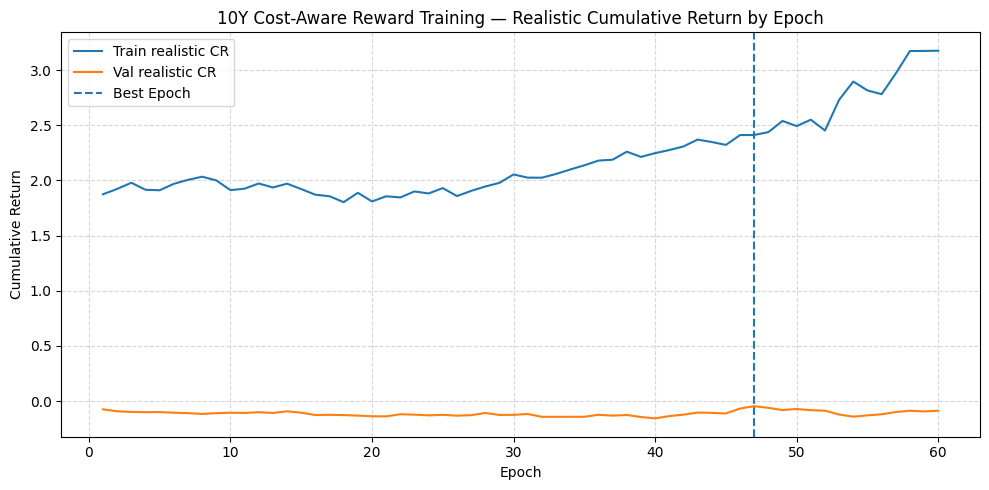

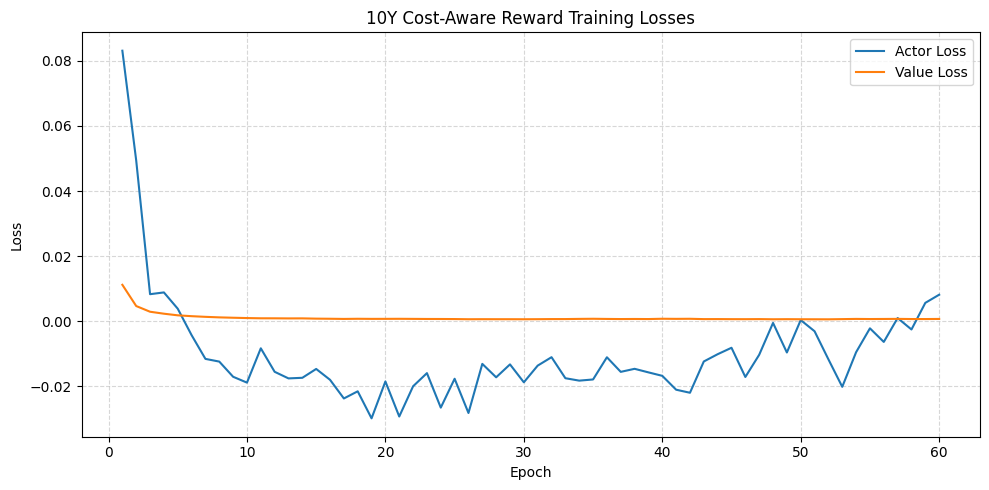

In [23]:
# ============================================================
# CELL 18 — Plot cost-aware 10Y training curves
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(cost_10y_history["epoch"], cost_10y_history["train_cumulative_return_realistic"], label="Train realistic CR")
plt.plot(cost_10y_history["epoch"], cost_10y_history["val_cumulative_return_realistic"], label="Val realistic CR")
plt.axvline(cost_10y_best_epoch, linestyle="--", label="Best Epoch")
plt.title("10Y Cost-Aware Reward Training — Realistic Cumulative Return by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cost_10y_history["epoch"], cost_10y_history["actor_loss_mean"], label="Actor Loss")
plt.plot(cost_10y_history["epoch"], cost_10y_history["value_loss_mean"], label="Value Loss")
plt.title("10Y Cost-Aware Reward Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

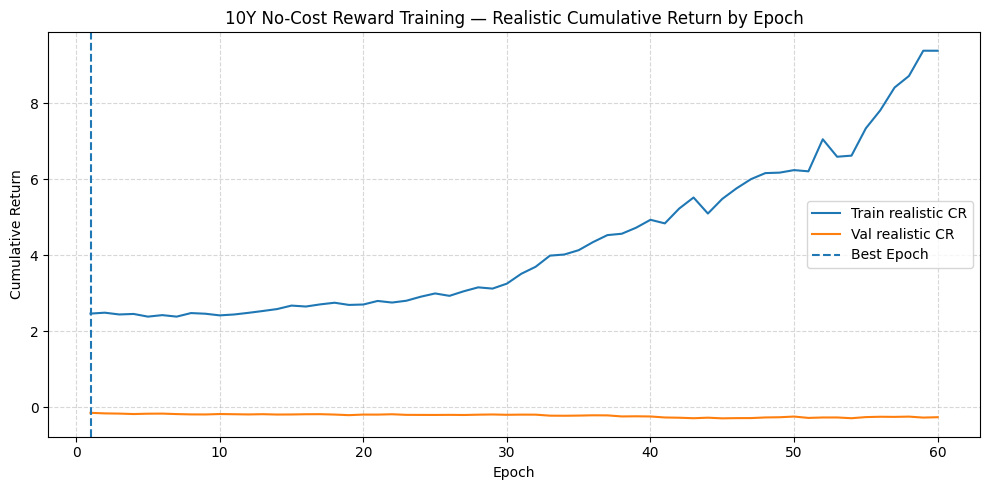

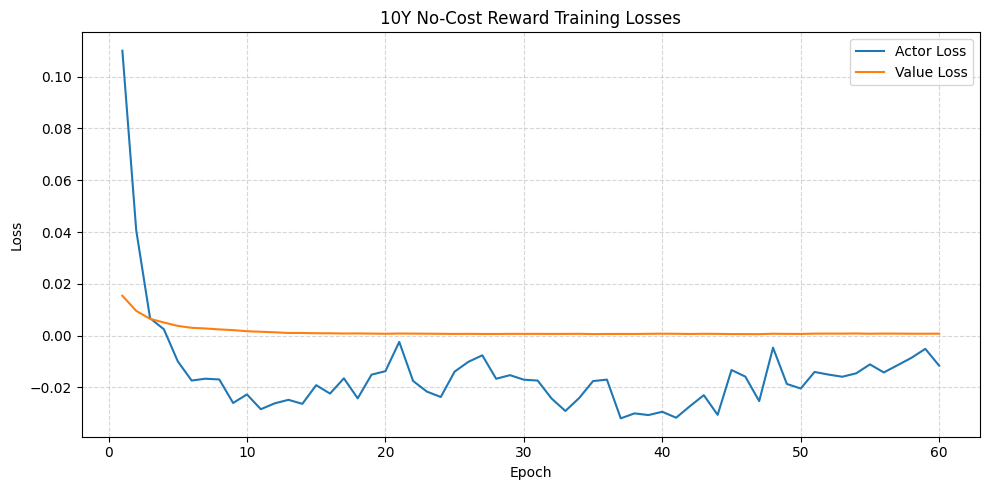

In [24]:
# ============================================================
# CELL 19 — Plot no-cost 10Y training curves
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(nocost_10y_history["epoch"], nocost_10y_history["train_cumulative_return_realistic"], label="Train realistic CR")
plt.plot(nocost_10y_history["epoch"], nocost_10y_history["val_cumulative_return_realistic"], label="Val realistic CR")
plt.axvline(nocost_10y_best_epoch, linestyle="--", label="Best Epoch")
plt.title("10Y No-Cost Reward Training — Realistic Cumulative Return by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(nocost_10y_history["epoch"], nocost_10y_history["actor_loss_mean"], label="Actor Loss")
plt.plot(nocost_10y_history["epoch"], nocost_10y_history["value_loss_mean"], label="Value Loss")
plt.title("10Y No-Cost Reward Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

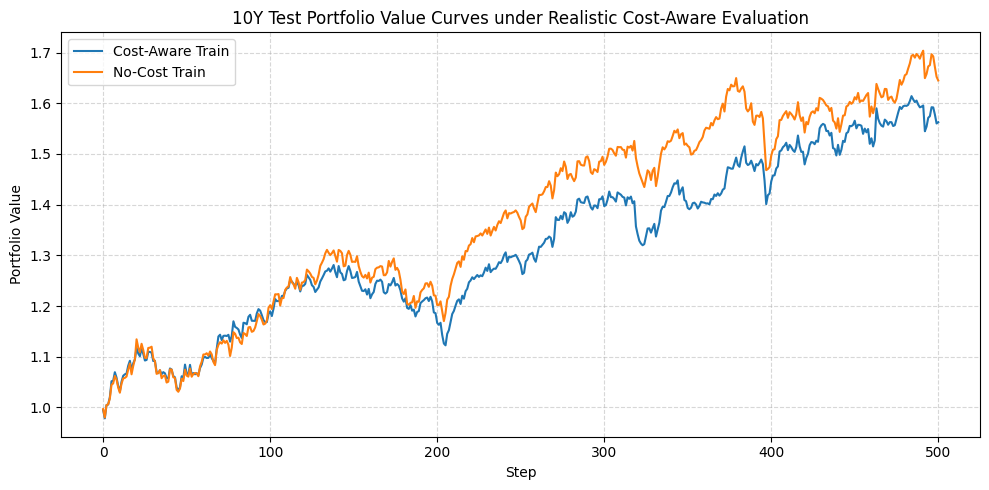

In [25]:
# ============================================================
# CELL 20 — Plot 10Y test portfolio value curves under realistic evaluation
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(realistic_rollouts["Transformer10Y_CostAwareTrain"]["test"]["portfolio_value"].values, label="Cost-Aware Train")
plt.plot(realistic_rollouts["Transformer10Y_NoCostTrain"]["test"]["portfolio_value"].values, label="No-Cost Train")
plt.title("10Y Test Portfolio Value Curves under Realistic Cost-Aware Evaluation")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# CELL 21 — Save reward comparison 10Y outputs
# ============================================================

realistic_10y_df.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_realistic_10y.csv", index=False)
frictionless_10y_df.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_frictionless_10y.csv", index=False)
reward_comparison_10y_df.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_all_10y.csv", index=False)
test_reward_10y_table.to_csv(f"{OUTPUTS_REWARD_DIR}/reward_comparison_test_10y.csv", index=False)

realistic_rollouts["Transformer10Y_CostAwareTrain"]["test"].to_csv(
    f"{OUTPUTS_REWARD_DIR}/costaware_train_test_rollout_realistic_10y.csv", index=False
)
realistic_rollouts["Transformer10Y_NoCostTrain"]["test"].to_csv(
    f"{OUTPUTS_REWARD_DIR}/nocost_train_test_rollout_realistic_10y.csv", index=False
)

print("Saved 10Y reward comparison outputs.")

Saved 10Y reward comparison outputs.


In [27]:
# ============================================================
# CELL 22 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_realistic_10y.csv",
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_frictionless_10y.csv",
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_all_10y.csv",
    f"{OUTPUTS_REWARD_DIR}/reward_comparison_test_10y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

assert len(realistic_10y_df) == 6
assert len(frictionless_10y_df) == 6

print("All 10Y reward comparison notebook checks passed.")

All 10Y reward comparison notebook checks passed.
